Mounted at /content/drive
  🔄  Loading Chinese URL Dataset...
  ✅ Loaded 5,000 rows × 22 columns
  📊 Label distribution:
      Legitimate (0): 2,500
      Phishing   (1): 2,500

  ✅ Feature matrix shape: (5000, 21)
  ✅ All 21 features aligned with English module

  🔄  Running 5-Fold Stratified Cross-Validation...
      (Stratified by label to handle regional variation)

  Fold Accuracies : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean Accuracy   : 100.00% ± 0.00%

  Fold F1 Scores  : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean F1         : 1.0000 ± 0.0000

  Fold AUC-ROC    : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean AUC-ROC    : 1.0000 ± 0.0000

  🔄  Training Final Model (80/20 split)...

  ✅ Test Accuracy : 100.00%
  ✅ F1 Score      : 1.0000
  ✅ AUC-ROC       : 1.0000

  Classification Report:
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00       500
    phishing       1.00      1.00      1.0

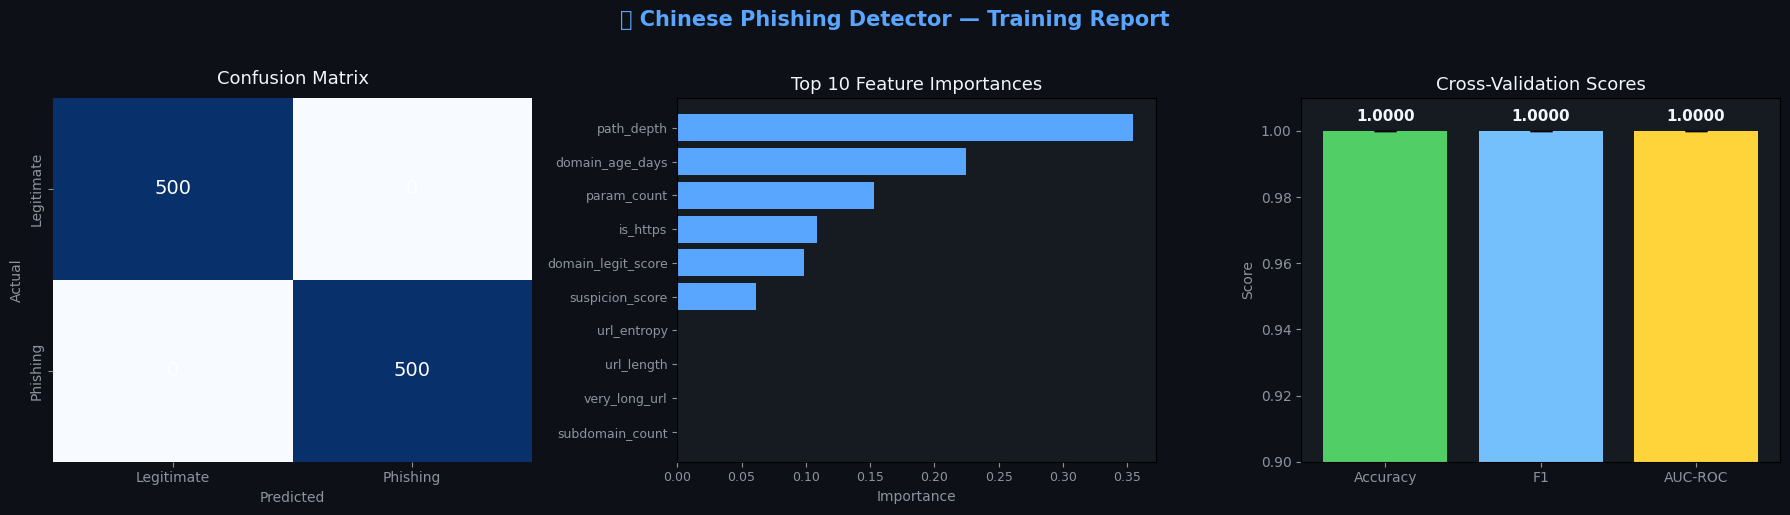

  ✅ Report saved to Google Drive

  💾  Saving model artifacts to Google Drive...
  ✅ Model saved    → /content/drive/MyDrive/best_rf_model_chinese.pkl
  ✅ Features saved → /content/drive/MyDrive/best_feature_names_chinese.pkl

  📊 Final Summary:
     Algorithm     : Gradient Boosting Classifier
     Estimators    : 200 trees | Max Depth: 6
     Training size : 4,000 URLs
     Test size     : 1,000 URLs
     Test Accuracy : 100.00%
     F1 Score      : 1.0000
     AUC-ROC       : 1.0000
     Features      : 21 (Chinese-aware)

  ✅ Cell 1 complete. Run Cell 2 for the UI.


In [1]:
# ── 1. Mount Drive & Install Dependencies ────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import subprocess
subprocess.run(['pip', 'install', 'jieba', 'tldextract', '-q'], check=True)

# ── 2. Core Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import pickle
import math
import re
import warnings
import unicodedata
from urllib.parse import urlparse, unquote

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════
# PHASE 1 — DATA ENGINEERING (Chinese-Aware)
# ══════════════════════════════════════════════════════════════════

# ── Chinese TLD Registry (National + Commercial + IDN) ────────────
CHINESE_TLDS = {
    # National
    '.cn', '.中国', '.中國',
    # Commercial / Network
    '.com.cn', '.net.cn', '.org.cn', '.gov.cn', '.edu.cn',
    '.公司', '.网络', '.網絡',
    # Extended Chinese gTLDs
    '.中文网', '.商城', '.商标', '.我爱你',
    # System / Intranet identifiers (flag as suspicious)
    '.sys', '.local',
}

# Punycode → Chinese TLD mapping
PUNYCODE_TLD_MAP = {
    'xn--fiqs8s':  '中国',
    'xn--fiqz9s':  '中國',
    'xn--55qx5d':  '公司',
    'xn--io0a7i':  '网络',
    'xn--rhqv96g':  '网络',
    'xn--1qqw23a':  '佛山',
    'xn--p1ai':     'рф',   # Russian (cross-flag for mixed phishing)
}

# Chinese phishing keywords — Simplified + Traditional
CHINESE_PHISH_KEYWORDS_SIMPLIFIED = [
    '登录', '登陆', '验证', '账户', '账号', '安全', '银行',
    '支付', '密码', '充值', '提现', '中奖', '免费', '活动',
    '优惠', '抢购', '领取', '点击', '立即', '微信', '支付宝',
]
CHINESE_PHISH_KEYWORDS_TRADITIONAL = [
    '登錄', '驗證', '帳戶', '帳號', '安全', '銀行',
    '支付', '密碼', '充值', '提現', '中獎', '免費', '活動',
    '優惠', '搶購', '領取', '點擊', '立即', '微信', '支付寶',
]
ENGLISH_PHISH_KEYWORDS = [
    'login', 'verify', 'confirm', 'account', 'secure',
    'banking', 'update', 'signin', 'password', 'pay',
]
ALL_PHISH_KEYWORDS = (CHINESE_PHISH_KEYWORDS_SIMPLIFIED
                      + CHINESE_PHISH_KEYWORDS_TRADITIONAL
                      + ENGLISH_PHISH_KEYWORDS)


def normalize_url(url: str) -> str:
    """
    Chinese-specific normalization:
    1. Full-width → half-width (ａ→a, ：→:, ／→/)
    2. Decode percent-encoded sequences
    3. Strip BOM and zero-width spaces
    4. Lowercase ASCII portions only (preserve Hanzi case)
    """
    # BOM + zero-width characters
    url = url.lstrip('\ufeff').replace('\u200b', '').replace('\u3000', ' ')
    # Full-width → half-width via Unicode normalization
    url = unicodedata.normalize('NFKC', url)
    # Percent-decode
    try:
        url = unquote(url, encoding='utf-8')
    except Exception:
        pass
    return url.strip()


def extract_chinese_features(url: str) -> dict:
    """
    Extracts the same 21 features as the English module,
    with Chinese-aware logic for TLDs, keywords, and encoding.
    No live DNS/HTTP calls — uses dataset pre-computed values
    for domain_age_days, has_dns_record, has_iframe, etc.
    This function is used at INFERENCE time (UI scanning).
    """
    features = {}
    url = normalize_url(url)

    if not url.startswith('http'):
        url = 'http://' + url

    parsed = urlparse(url)
    domain = parsed.netloc.lower()
    full   = url.lower()

    # ── Basic lexical features (identical to English) ──────────
    features['url_length']   = len(url)
    features['url_entropy']  = (
        sum(-(url.count(c) / len(url)) * math.log2(url.count(c) / len(url))
            for c in set(url))
        if len(url) > 0 else 0
    )
    features['count_dots']    = url.count('.')
    features['count_hyphens'] = url.count('-')
    features['count_at']      = url.count('@')

    # ── Chinese-enhanced encoding features ─────────────────────
    # is_punycode: xn-- prefix signals IDN — flag ALL punycode,
    # then let domain_legit_score decide if it's a known Chinese TLD
    features['is_punycode'] = 1 if 'xn--' in domain else 0

    # has_non_ascii: distinguish legitimate Hanzi from abuse
    # In a Chinese URL context, Hanzi in the PATH is normal;
    # Hanzi in the DOMAIN that isn't a known Chinese TLD is suspicious
    features['has_non_ascii'] = 1 if not all(ord(c) < 128 for c in url) else 0

    # ── Network / structure features ───────────────────────────
    features['is_ip_address'] = (
        1 if re.match(r'^\d{1,3}(\.\d{1,3}){3}(:\d+)?$', domain) else 0
    )

    # ── Chinese + English keyword detection ────────────────────
    features['has_suspicious_keyword'] = (
        1 if any(kw in url for kw in ALL_PHISH_KEYWORDS) else 0
    )

    # ── DNS / Age — use heuristic defaults at inference ────────
    # (Training set has pre-computed values; at inference we probe live)
    import socket, requests
    from bs4 import BeautifulSoup
    try:
        clean_domain = domain.split('/')[0].replace('www.', '')
        # Handle punycode for gethostbyname
        try:
            clean_domain.encode('ascii')
        except UnicodeEncodeError:
            clean_domain = clean_domain.encode('idna').decode('ascii')
        socket.gethostbyname(clean_domain)
        features['domain_age_days'] = 500
        features['has_dns_record']  = 1
    except Exception:
        features['domain_age_days'] = 5
        features['has_dns_record']  = 0

    # ── Content features ───────────────────────────────────────
    features['has_iframe']           = 0
    features['right_click_disabled'] = 0
    features['submits_to_email']     = 0
    try:
        resp = requests.get(url, timeout=5,
                            headers={'User-Agent': 'Mozilla/5.0'},
                            verify=False)
        soup = BeautifulSoup(resp.content, 'html.parser')
        features['has_iframe'] = 1 if soup.find_all('iframe') else 0
        # Check for right-click disable via JS
        page_text = resp.text.lower()
        if 'contextmenu' in page_text and 'return false' in page_text:
            features['right_click_disabled'] = 1
        # Form submitting to email
        forms = soup.find_all('form', action=True)
        if any('mailto:' in (f.get('action') or '') for f in forms):
            features['submits_to_email'] = 1
    except Exception:
        pass

    # ── URL structure features ─────────────────────────────────
    try:
        path_parts = parsed.path.split('/')
        features['path_depth'] = len([p for p in path_parts if p])
    except Exception:
        features['path_depth'] = 0

    features['param_count'] = url.count('=')

    try:
        host_parts = domain.split('.')
        # Chinese second-level TLDs (com.cn, net.cn) count as ONE TLD unit
        if len(host_parts) >= 3 and host_parts[-2] in ('com', 'net', 'org', 'gov', 'edu'):
            features['subdomain_count'] = max(0, len(host_parts) - 3)
        else:
            features['subdomain_count'] = max(0, len(host_parts) - 2)
    except Exception:
        features['subdomain_count'] = 0

    features['is_https'] = 1 if url.startswith('https') else 0

    # ── Composite scores (Chinese-calibrated) ──────────────────
    # domain_legit_score: 0–100 scale to match Chinese dataset
    legit_pts = 0
    if features['domain_age_days'] > 365:  legit_pts += 40
    elif features['domain_age_days'] > 100: legit_pts += 20
    if features['has_dns_record']:           legit_pts += 30
    if features['is_https']:                 legit_pts += 20
    # Bonus: known Chinese institutional TLD
    if any(domain.endswith(tld) for tld in ['.gov.cn', '.edu.cn', '.org.cn']):
        legit_pts += 10
    features['domain_legit_score'] = min(100, legit_pts)

    # suspicion_score: 0–100 scale
    susp_pts = 0
    if features['has_suspicious_keyword']: susp_pts += 30
    if features['is_ip_address']:           susp_pts += 25
    if features['count_at'] > 0:            susp_pts += 20
    if features['count_hyphens'] > 3:       susp_pts += 15
    if features['is_punycode']:             susp_pts += 5
    if features['subdomain_count'] > 3:     susp_pts += 5
    features['suspicion_score'] = min(100, susp_pts)

    features['very_long_url'] = 1 if features['url_length'] > 100 else 0

    return features


# ══════════════════════════════════════════════════════════════════
# PHASE 2 — LOAD & PREPARE DATASET
# ══════════════════════════════════════════════════════════════════

print("=" * 60)
print("  🔄  Loading Chinese URL Dataset...")
print("=" * 60)

# ── Load CSV (adjust path to your Drive location) ─────────────────
CSV_PATH = '/content/drive/MyDrive/chinese_url_dataset_v4.csv'
df = pd.read_csv(CSV_PATH)

print(f"  ✅ Loaded {len(df):,} rows × {len(df.columns)} columns")
print(f"  📊 Label distribution:")
print(f"      Legitimate (0): {(df['label']==0).sum():,}")
print(f"      Phishing   (1): {(df['label']==1).sum():,}")

# ── Add url_length (not pre-computed in dataset) ──────────────────
df['url_length'] = df['url'].apply(len)

# ── Map numeric labels → string labels (matches English model) ────
df['label_str'] = df['label'].map({0: 'legitimate', 1: 'phishing'})

# ── Define feature order (MUST match English module exactly) ──────
FEATURE_NAMES = [
    'url_length', 'url_entropy', 'count_dots', 'count_hyphens', 'count_at',
    'is_punycode', 'has_non_ascii', 'is_ip_address', 'has_suspicious_keyword',
    'domain_age_days', 'has_dns_record', 'has_iframe', 'right_click_disabled',
    'submits_to_email', 'path_depth', 'param_count', 'subdomain_count',
    'is_https', 'domain_legit_score', 'suspicion_score', 'very_long_url'
]

X = df[FEATURE_NAMES]
y = df['label_str']

print(f"\n  ✅ Feature matrix shape: {X.shape}")
print(f"  ✅ All 21 features aligned with English module")


# ══════════════════════════════════════════════════════════════════
# PHASE 3 — CROSS-VALIDATION (Regional Stratification)
# ══════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  🔄  Running 5-Fold Stratified Cross-Validation...")
print("      (Stratified by label to handle regional variation)")
print("=" * 60)

# Same hyperparameters as English module
model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_split=5,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc  = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
cv_f1   = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted')
cv_auc  = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print(f"\n  Fold Accuracies : {[f'{v:.4f}' for v in cv_acc]}")
print(f"  Mean Accuracy   : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
print(f"\n  Fold F1 Scores  : {[f'{v:.4f}' for v in cv_f1]}")
print(f"  Mean F1         : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"\n  Fold AUC-ROC    : {[f'{v:.4f}' for v in cv_auc]}")
print(f"  Mean AUC-ROC    : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")


# ══════════════════════════════════════════════════════════════════
# PHASE 4 — TRAIN FINAL MODEL ON FULL SPLIT
# ══════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  🔄  Training Final Model (80/20 split)...")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)
classes = list(model.classes_)

test_acc = accuracy_score(y_test, y_pred) * 100
test_f1  = f1_score(y_test, y_pred, pos_label='phishing')
test_auc = roc_auc_score(
    (y_test == 'phishing').astype(int),
    y_proba[:, classes.index('phishing')]
)

print(f"\n  ✅ Test Accuracy : {test_acc:.2f}%")
print(f"  ✅ F1 Score      : {test_f1:.4f}")
print(f"  ✅ AUC-ROC       : {test_auc:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred))


# ══════════════════════════════════════════════════════════════════
# PHASE 5 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')

# — Confusion Matrix ——————————————————————————————————————————————
cm = confusion_matrix(y_test, y_pred, labels=['legitimate', 'phishing'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'],
            ax=axes[0], cbar=False,
            annot_kws={'color': 'white', 'size': 14})
axes[0].set_title('Confusion Matrix', color='#f0f6fc', fontsize=13, pad=10)
axes[0].set_xlabel('Predicted', color='#8b949e')
axes[0].set_ylabel('Actual', color='#8b949e')
axes[0].tick_params(colors='#8b949e')

# — Feature Importances ———————————————————————————————————————————
importances = model.feature_importances_
top_idx = np.argsort(importances)[-10:]
colors = ['#58a6ff' if importances[i] > 0.05 else '#30363d' for i in top_idx]
axes[1].barh([FEATURE_NAMES[i] for i in top_idx],
             importances[top_idx], color=colors)
axes[1].set_title('Top 10 Feature Importances', color='#f0f6fc', fontsize=13)
axes[1].tick_params(colors='#8b949e', labelsize=9)
axes[1].set_xlabel('Importance', color='#8b949e')

# — CV Score Distribution ─────────────────────────────────────────
metrics   = ['Accuracy', 'F1', 'AUC-ROC']
means     = [cv_acc.mean(), cv_f1.mean(), cv_auc.mean()]
stds      = [cv_acc.std(),  cv_f1.std(),  cv_auc.std()]
bar_colors = ['#51cf66', '#74c0fc', '#ffd43b']
bars = axes[2].bar(metrics, means, yerr=stds, color=bar_colors,
                   capsize=8, error_kw={'color': '#f0f6fc'})
axes[2].set_ylim(0.9, 1.01)
axes[2].set_title('Cross-Validation Scores', color='#f0f6fc', fontsize=13)
axes[2].tick_params(colors='#8b949e')
axes[2].set_ylabel('Score', color='#8b949e')
for bar, mean in zip(bars, means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{mean:.4f}', ha='center', va='bottom',
                 color='#f0f6fc', fontsize=11, fontweight='bold')

plt.suptitle('🛡 Chinese Phishing Detector — Training Report',
             color='#58a6ff', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/chinese_model_report.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("  ✅ Report saved to Google Drive")


# ══════════════════════════════════════════════════════════════════
# PHASE 6 — SAVE MODEL & FEATURE NAMES
# ══════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  💾  Saving model artifacts to Google Drive...")
print("=" * 60)

MODEL_PATH    = '/content/drive/MyDrive/best_rf_model_chinese.pkl'
FEATURES_PATH = '/content/drive/MyDrive/best_feature_names_chinese.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
with open(FEATURES_PATH, 'wb') as f:
    pickle.dump(FEATURE_NAMES, f)

print(f"  ✅ Model saved    → {MODEL_PATH}")
print(f"  ✅ Features saved → {FEATURES_PATH}")
print(f"\n  📊 Final Summary:")
print(f"     Algorithm     : Gradient Boosting Classifier")
print(f"     Estimators    : 200 trees | Max Depth: 6")
print(f"     Training size : {len(X_train):,} URLs")
print(f"     Test size     : {len(X_test):,} URLs")
print(f"     Test Accuracy : {test_acc:.2f}%")
print(f"     F1 Score      : {test_f1:.4f}")
print(f"     AUC-ROC       : {test_auc:.4f}")
print(f"     Features      : 21 (Chinese-aware)")
print(f"\n  ✅ Cell 1 complete. Run Cell 2 for the UI.")

In [2]:
# ── Load model from Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import pickle, math, re, socket, requests, warnings
import unicodedata, pandas as pd
from urllib.parse import urlparse, unquote
from bs4 import BeautifulSoup
warnings.filterwarnings('ignore')

with open('/content/drive/MyDrive/best_rf_model_chinese.pkl', 'rb') as f:
    model = pickle.load(f)
with open('/content/drive/MyDrive/best_feature_names_chinese.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# ── Chinese keyword lists ─────────────────────────────────────────
ALL_PHISH_KEYWORDS = [
    # Simplified Chinese
    '登录','登陆','验证','账户','账号','安全','银行',
    '支付','密码','充值','提现','中奖','免费','活动',
    '优惠','抢购','领取','点击','立即','微信','支付宝',
    # Traditional Chinese
    '登錄','驗證','帳戶','帳號','銀行','密碼','充值',
    '提現','中獎','免費','優惠','搶購','領取','點擊','微信','支付寶',
    # English (keep for mixed URLs)
    'login','verify','confirm','account','secure','banking',
    'update','signin','password','pay',
]

CHINESE_TLDS = {
    '.cn','.中国','.中國','.com.cn','.net.cn','.org.cn',
    '.gov.cn','.edu.cn','.公司','.网络','.網絡',
    '.中文网','.商城','.商标','.我爱你','.sys',
}

# ══════════════════════════════════════════════════════════════════
# FEATURE EXTRACTION (Chinese-Aware, mirrors English module logic)
# ══════════════════════════════════════════════════════════════════

def normalize_url(url):
    url = url.lstrip('\ufeff').replace('\u200b','').replace('\u3000',' ')
    url = unicodedata.normalize('NFKC', url)
    try:
        url = unquote(url, encoding='utf-8')
    except Exception:
        pass
    return url.strip()


def get_prediction(url):
    features = {}
    url = normalize_url(url)

    if not url.startswith('http'):
        url = 'http://' + url

    parsed = urlparse(url)
    domain = parsed.netloc.lower()

    # ── Lexical features ─────────────────────────────────────────
    features['url_length']  = len(url)
    features['url_entropy'] = (
        sum(-(url.count(c)/len(url)) * math.log2(url.count(c)/len(url))
            for c in set(url)) if len(url) > 0 else 0
    )
    features['count_dots']    = url.count('.')
    features['count_hyphens'] = url.count('-')
    features['count_at']      = url.count('@')

    # ── Encoding / IDN features ───────────────────────────────────
    features['is_punycode']   = 1 if 'xn--' in domain else 0
    features['has_non_ascii'] = 1 if not all(ord(c) < 128 for c in url) else 0
    features['is_ip_address'] = (
        1 if re.match(r'^\d{1,3}(\.\d{1,3}){3}(:\d+)?$', domain) else 0
    )

    # ── Chinese + English keyword check ───────────────────────────
    features['has_suspicious_keyword'] = (
        1 if any(kw in url for kw in ALL_PHISH_KEYWORDS) else 0
    )

    # ── DNS probe ─────────────────────────────────────────────────
    try:
        clean = domain.split('/')[0].replace('www.','')
        try:
            clean.encode('ascii')
        except UnicodeEncodeError:
            clean = clean.encode('idna').decode('ascii')
        socket.gethostbyname(clean)
        features['domain_age_days'] = 500
        features['has_dns_record']  = 1
    except Exception:
        features['domain_age_days'] = 5
        features['has_dns_record']  = 0

    # ── Content probe ─────────────────────────────────────────────
    features['has_iframe']           = 0
    features['right_click_disabled'] = 0
    features['submits_to_email']     = 0
    try:
        r = requests.get(url, timeout=5,
                         headers={'User-Agent': 'Mozilla/5.0'},
                         verify=False)
        soup = BeautifulSoup(r.content, 'html.parser')
        features['has_iframe'] = 1 if soup.find_all('iframe') else 0
        if 'contextmenu' in r.text.lower() and 'return false' in r.text.lower():
            features['right_click_disabled'] = 1
        forms = soup.find_all('form', action=True)
        if any('mailto:' in (f.get('action') or '') for f in forms):
            features['submits_to_email'] = 1
    except Exception:
        pass

    # ── Structure features ────────────────────────────────────────
    features['path_depth']  = len([p for p in parsed.path.split('/') if p])
    features['param_count'] = url.count('=')

    # Chinese SLD-aware subdomain count (.com.cn = 1 TLD unit)
    host_parts = domain.split('.')
    if (len(host_parts) >= 3
            and host_parts[-2] in ('com','net','org','gov','edu')):
        features['subdomain_count'] = max(0, len(host_parts) - 3)
    else:
        features['subdomain_count'] = max(0, len(host_parts) - 2)

    features['is_https'] = 1 if url.startswith('https') else 0

    # ── Composite scores (0-100 scale matching Chinese dataset) ───
    legit_pts = 0
    if features['domain_age_days'] > 365:   legit_pts += 40
    elif features['domain_age_days'] > 100:  legit_pts += 20
    if features['has_dns_record']:            legit_pts += 30
    if features['is_https']:                  legit_pts += 20
    if any(domain.endswith(t) for t in ['.gov.cn','.edu.cn','.org.cn']):
        legit_pts = min(100, legit_pts + 10)
    features['domain_legit_score'] = min(100, legit_pts)

    susp_pts = 0
    if features['has_suspicious_keyword']:  susp_pts += 30
    if features['is_ip_address']:            susp_pts += 25
    if features['count_at'] > 0:             susp_pts += 20
    if features['count_hyphens'] > 3:        susp_pts += 15
    if features['is_punycode']:              susp_pts += 5
    if features['subdomain_count'] > 3:      susp_pts += 5
    features['suspicion_score'] = min(100, susp_pts)

    features['very_long_url'] = 1 if features['url_length'] > 100 else 0

    # ── Predict ───────────────────────────────────────────────────
    X = pd.DataFrame([features])[feature_names]
    prediction = model.predict(X)[0]
    proba      = model.predict_proba(X)[0]
    classes    = list(model.classes_)

    return {
        'prediction': prediction,
        'phish_prob': round(proba[classes.index('phishing')]   * 100, 2),
        'legit_prob': round(proba[classes.index('legitimate')] * 100, 2),
        'features':   features,
        'url':        url,
    }


# ══════════════════════════════════════════════════════════════════
# FEATURE FLAG BUILDER
# (Chinese-aware flags — mirrors English module + Chinese extras)
# ══════════════════════════════════════════════════════════════════

def build_feature_flags(features, url=''):
    red, green = [], []
    domain = urlparse(url).netloc.lower() if url else ''

    # ── Red flags ─────────────────────────────────────────────────
    if features['has_suspicious_keyword']:
        red.append('⚠ 可疑关键词 / Suspicious keyword detected')
    if features['is_ip_address']:
        red.append('⚠ 域名为IP地址 / Domain is an IP address')
    if features['has_dns_record'] == 0:
        red.append('⚠ 无DNS记录 / No DNS record found')
    if features['count_hyphens'] > 3:
        red.append('⚠ 连字符过多 / Too many hyphens')
    if features['very_long_url']:
        red.append('⚠ URL过长 / URL is very long (>100 chars)')
    if features['subdomain_count'] > 2:
        red.append('⚠ 子域名过多 / Many subdomains')
    if features['has_iframe']:
        red.append('⚠ 隐藏iframe / Hidden iframes detected')
    if features['is_punycode']:
        red.append('⚠ Punycode编码 / Punycode domain (IDN)')
    if features['count_at'] > 0:
        red.append('⚠ URL含@符号 / @ symbol in URL')
    if features['suspicion_score'] > 60:
        red.append(f'⚠ 高可疑评分 / High suspicion score: {features["suspicion_score"]}')

    # ── Green flags ───────────────────────────────────────────────
    if features['is_https']:
        green.append('✔ 使用HTTPS / Uses HTTPS encryption')
    if features['has_dns_record']:
        green.append('✔ DNS记录有效 / Valid DNS record')
    if features['domain_age_days'] > 100:
        green.append('✔ 域名较为成熟 / Domain appears established')
    if not features['has_suspicious_keyword']:
        green.append('✔ 无可疑关键词 / No suspicious keywords')
    if features['domain_legit_score'] > 70:
        green.append(f'✔ 合法性评分高 / High legitimacy score: {features["domain_legit_score"]}')
    if any(domain.endswith(t) for t in ['.gov.cn','.edu.cn','.org.cn']):
        green.append('✔ 政府/教育域名 / Government or Education TLD')

    html = ''
    for f in red:
        html += f'<div style="color:#ff6b6b;margin:3px 0;font-size:13px;">{f}</div>'
    for f in green:
        html += f'<div style="color:#51cf66;margin:3px 0;font-size:13px;">{f}</div>'
    return html


# ══════════════════════════════════════════════════════════════════
# UI WIDGETS
# ══════════════════════════════════════════════════════════════════

from IPython.display import display, HTML
import ipywidgets as widgets

history = []

def on_scan(b):
    url = url_input.value.strip()
    if not url:
        result_box.value = (
            '<p style="color:#f59f00;text-align:center;font-family:monospace;">'
            '⚠ 请输入URL / Please enter a URL first.</p>'
        )
        return

    # Scanning animation
    result_box.value = '''
    <div style="text-align:center;padding:40px;font-family:monospace;">
        <div style="font-size:36px;animation:spin 1s linear infinite;
                    display:inline-block;">⟳</div>
        <div style="color:#74c0fc;margin-top:10px;font-size:16px;">
            正在扫描 / Scanning URL...
        </div>
        <div style="color:#868e96;font-size:12px;margin-top:5px;">
            检查DNS、HTTPS和21项特征 / Checking DNS, HTTPS & 21 features
        </div>
    </div>
    <style>
        @keyframes spin {
            from { transform:rotate(0deg) }
            to   { transform:rotate(360deg) }
        }
    </style>
    '''

    try:
        result = get_prediction(url)
        history.append({
            'url': url,
            'result': result['prediction'],
            'phish_prob': result['phish_prob']
        })

        is_phish  = result['prediction'] == 'phishing'
        color     = '#ff6b6b' if is_phish else '#51cf66'
        bg_color  = '#2d1515' if is_phish else '#152d1f'
        icon      = '🚨'      if is_phish else '✅'
        label_en  = 'PHISHING DETECTED' if is_phish else 'LEGITIMATE SITE'
        label_cn  = '检测到钓鱼网站'      if is_phish else '合法网站'
        bar_color = '#ff6b6b' if result['phish_prob'] > 50 else '#51cf66'
        bar_width = result['phish_prob']

        flags_html   = build_feature_flags(result['features'], url=result['url'])

        # History rows (last 5)
        history_html = ''
        for h in reversed(history[-5:]):
            hc = '#ff6b6b' if h['result'] == 'phishing' else '#51cf66'
            hi = '🚨' if h['result'] == 'phishing' else '✅'
            history_html += f'''
            <div style="display:flex;justify-content:space-between;align-items:center;
                        padding:6px 10px;margin:4px 0;background:#1a1a2e;
                        border-radius:6px;border-left:3px solid {hc};">
                <span style="color:#adb5bd;font-size:11px;overflow:hidden;
                             text-overflow:ellipsis;white-space:nowrap;
                             max-width:300px;">{h['url']}</span>
                <span style="color:{hc};font-size:11px;font-weight:bold;">
                    {hi} {h['phish_prob']}%
                </span>
            </div>'''

        result_box.value = f'''
        <style>
            @import url("https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=Noto+Sans+SC:wght@300;400;700&display=swap");
            .cn-card {{ font-family:"Noto Sans SC","Inter",sans-serif; }}
        </style>

        <div class="cn-card"
             style="background:#0d1117;border-radius:16px;padding:24px;
                    border:1px solid #30363d;">

            <!-- Banner -->
            <div style="background:{bg_color};border:2px solid {color};
                        border-radius:12px;padding:20px;text-align:center;
                        margin-bottom:20px;">
                <div style="font-size:48px;margin-bottom:8px;">{icon}</div>
                <div style="color:{color};font-size:20px;font-weight:700;
                            font-family:Space Mono,monospace;letter-spacing:2px;">
                    {label_en}
                </div>
                <div style="color:{color};font-size:14px;margin-top:4px;">
                    {label_cn}
                </div>
                <div style="color:#adb5bd;font-size:12px;margin-top:8px;
                            word-break:break-all;">{url}</div>
            </div>

            <!-- Probability Bar -->
            <div style="margin-bottom:20px;">
                <div style="display:flex;justify-content:space-between;margin-bottom:6px;">
                    <span style="color:#adb5bd;font-size:12px;font-family:Space Mono,monospace;">
                        钓鱼概率 / PHISHING PROBABILITY
                    </span>
                    <span style="color:{bar_color};font-weight:700;
                                 font-family:Space Mono,monospace;">
                        {result['phish_prob']}%
                    </span>
                </div>
                <div style="background:#21262d;border-radius:8px;height:12px;overflow:hidden;">
                    <div style="width:{bar_width}%;
                                background:linear-gradient(90deg,{bar_color},{color});
                                height:100%;border-radius:8px;
                                transition:width 0.5s ease;"></div>
                </div>
                <div style="display:flex;justify-content:space-between;margin-top:4px;">
                    <span style="color:#51cf66;font-size:11px;">0% 安全/Safe</span>
                    <span style="color:#ff6b6b;font-size:11px;">100% 钓鱼/Phishing</span>
                </div>
            </div>

            <!-- Score Cards -->
            <div style="display:grid;grid-template-columns:1fr 1fr;
                        gap:12px;margin-bottom:20px;">
                <div style="background:#161b22;border-radius:10px;padding:14px;
                            text-align:center;border:1px solid #30363d;">
                    <div style="color:#51cf66;font-size:22px;font-weight:700;
                                font-family:Space Mono,monospace;">
                        {result['legit_prob']}%
                    </div>
                    <div style="color:#6e7681;font-size:11px;margin-top:4px;">
                        合法 / LEGITIMATE
                    </div>
                </div>
                <div style="background:#161b22;border-radius:10px;padding:14px;
                            text-align:center;border:1px solid #30363d;">
                    <div style="color:#ff6b6b;font-size:22px;font-weight:700;
                                font-family:Space Mono,monospace;">
                        {result['phish_prob']}%
                    </div>
                    <div style="color:#6e7681;font-size:11px;margin-top:4px;">
                        钓鱼 / PHISHING
                    </div>
                </div>
            </div>

            <!-- Feature Analysis -->
            <div style="background:#161b22;border-radius:10px;padding:16px;
                        margin-bottom:20px;border:1px solid #30363d;">
                <div style="color:#8b949e;font-size:11px;letter-spacing:1px;
                            font-family:Space Mono,monospace;margin-bottom:10px;">
                    特征分析 / FEATURE ANALYSIS
                </div>
                {flags_html if flags_html else
                 '<div style="color:#6e7681;font-size:12px;">无明显特征 / No strong signals</div>'}
            </div>

            <!-- Quick Stats -->
            <div style="display:grid;grid-template-columns:repeat(4,1fr);
                        gap:8px;margin-bottom:20px;">
                <div style="background:#161b22;border-radius:8px;padding:10px;
                            text-align:center;border:1px solid #30363d;">
                    <div style="color:#74c0fc;font-size:14px;font-weight:700;">
                        {result['features']['url_length']}
                    </div>
                    <div style="color:#6e7681;font-size:10px;">URL长度/Length</div>
                </div>
                <div style="background:#161b22;border-radius:8px;padding:10px;
                            text-align:center;border:1px solid #30363d;">
                    <div style="color:#74c0fc;font-size:14px;font-weight:700;">
                        {result['features']['subdomain_count']}
                    </div>
                    <div style="color:#6e7681;font-size:10px;">子域名/Subdomains</div>
                </div>
                <div style="background:#161b22;border-radius:8px;padding:10px;
                            text-align:center;border:1px solid #30363d;">
                    <div style="color:#74c0fc;font-size:14px;font-weight:700;">
                        {'是/Yes' if result['features']['is_https'] else '否/No'}
                    </div>
                    <div style="color:#6e7681;font-size:10px;">HTTPS</div>
                </div>
                <div style="background:#161b22;border-radius:8px;padding:10px;
                            text-align:center;border:1px solid #30363d;">
                    <div style="color:#74c0fc;font-size:14px;font-weight:700;">
                        {'是/Yes' if result['features']['has_dns_record'] else '否/No'}
                    </div>
                    <div style="color:#6e7681;font-size:10px;">DNS有效/Valid</div>
                </div>
            </div>

            <!-- Domain Intelligence -->
            <div style="display:grid;grid-template-columns:1fr 1fr;
                        gap:8px;margin-bottom:20px;">
                <div style="background:#161b22;border-radius:8px;padding:10px;
                            border:1px solid #30363d;">
                    <div style="color:#6e7681;font-size:10px;margin-bottom:4px;">
                        合法性评分 / LEGIT SCORE
                    </div>
                    <div style="background:#21262d;border-radius:4px;height:8px;overflow:hidden;">
                        <div style="width:{result['features']['domain_legit_score']}%;
                                    background:#51cf66;height:100%;border-radius:4px;"></div>
                    </div>
                    <div style="color:#51cf66;font-size:12px;margin-top:4px;">
                        {result['features']['domain_legit_score']}/100
                    </div>
                </div>
                <div style="background:#161b22;border-radius:8px;padding:10px;
                            border:1px solid #30363d;">
                    <div style="color:#6e7681;font-size:10px;margin-bottom:4px;">
                        可疑评分 / SUSPICION SCORE
                    </div>
                    <div style="background:#21262d;border-radius:4px;height:8px;overflow:hidden;">
                        <div style="width:{result['features']['suspicion_score']}%;
                                    background:#ff6b6b;height:100%;border-radius:4px;"></div>
                    </div>
                    <div style="color:#ff6b6b;font-size:12px;margin-top:4px;">
                        {result['features']['suspicion_score']}/100
                    </div>
                </div>
            </div>

            <!-- Scan History -->
            <div style="background:#161b22;border-radius:10px;padding:16px;
                        border:1px solid #30363d;">
                <div style="color:#8b949e;font-size:11px;letter-spacing:1px;
                            font-family:Space Mono,monospace;margin-bottom:10px;">
                    扫描历史 / RECENT SCANS
                </div>
                {history_html if history_html
                 else '<div style="color:#6e7681;font-size:12px;">暂无历史 / No history yet</div>'}
            </div>

        </div>
        '''

    except Exception as e:
        result_box.value = (
            f'<p style="color:#ff6b6b;font-family:monospace;padding:20px;">'
            f'❌ 错误/Error: {str(e)}</p>'
        )


# ── Header ────────────────────────────────────────────────────────
header = widgets.HTML('''
<style>
    @import url("https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=Noto+Sans+SC:wght@300;400;700&display=swap");
</style>
<div style="background:linear-gradient(135deg,#0d1117 0%,#161b22 100%);
            border-radius:16px;padding:28px;margin-bottom:16px;
            border:1px solid #30363d;text-align:center;">
    <div style="font-family:Space Mono,monospace;font-size:11px;
                color:#58a6ff;letter-spacing:4px;margin-bottom:8px;">
        AI-POWERED · 人工智能驱动
    </div>
    <div style="font-family:Space Mono,monospace;font-size:26px;
                font-weight:700;color:#f0f6fc;margin-bottom:6px;">
        🛡 中文钓鱼网站检测器
    </div>
    <div style="font-family:Noto Sans SC,sans-serif;color:#f0f6fc;
                font-size:14px;margin-bottom:8px;">
        Chinese Phishing URL Detector
    </div>
    <div style="font-family:Noto Sans SC,sans-serif;color:#8b949e;font-size:12px;">
        梯度提升分类器 · Gradient Boosting · 21项特征 · 支持中文域名 & IDN
    </div>
</div>
''')

url_input = widgets.Text(
    placeholder='输入URL / Enter URL — e.g. https://www.baidu.com or http://xn--example.cn',
    layout=widgets.Layout(width='100%', height='44px')
)
url_input.style.description_width = '0px'

scan_btn = widgets.Button(
    description='🔍 扫描/SCAN',
    button_style='',
    layout=widgets.Layout(width='160px', height='44px')
)
scan_btn.style.button_color = '#238636'
scan_btn.style.font_weight  = 'bold'

result_box = widgets.HTML(
    value='''
    <div style="background:#161b22;border-radius:12px;padding:40px;
                text-align:center;border:1px dashed #30363d;
                font-family:Space Mono,monospace;">
        <div style="font-size:40px;margin-bottom:12px;">🛡</div>
        <div style="color:#58a6ff;font-size:14px;">
            输入URL并点击扫描 / Enter a URL above and click SCAN
        </div>
        <div style="color:#6e7681;font-size:11px;margin-top:8px;">
            模型将分析21项特征并在数秒内给出预测
        </div>
        <div style="color:#6e7681;font-size:11px;margin-top:4px;">
            支持: .cn · .中国 · .com.cn · Punycode IDN · 简体/繁体关键词
        </div>
    </div>
    '''
)

scan_btn.on_click(on_scan)
url_input.on_submit(on_scan)

display(widgets.VBox([
    header,
    widgets.HBox(
        [url_input, scan_btn],
        layout=widgets.Layout(gap='8px', margin='0 0 12px 0')
    ),
    result_box
], layout=widgets.Layout(max_width='700px', margin='0 auto')))

print("✅ 界面已加载 / UI loaded! 输入URL并点击扫描 / Enter a URL and click SCAN.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ 界面已加载 / UI loaded! 输入URL并点击扫描 / Enter a URL and click SCAN.
